## 1. Loading Dataset & Initial Audit

**Process:** We import the raw transactional data from the SuperStore CSV. This step initializes our analysis environment and allows us to inspect the raw schema, identifying primary keys (Order ID) and potential target variables (Profit/Sales).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

df = pd.read_csv('SuperStoreOrders.csv')
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 51290
Columns: 21


In [ ]:
# Understand the data types, columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

## 2. Data Cleaning & Standardization

**Process:** To ensure analytical integrity, we perform the following:
*   **Whitespace Removal:** Cleaning string entries to prevent grouping errors.
*   **Type Casting:** Converting date strings to datetime objects and ensuring monetary values are floats.
*   **Integrity Check:** Verifying that shipping dates occur after order dates.
*   **Deduplication:** Removing redundant records to prevent inflated metrics.

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
#Removing all empty spaces from the dataset
df.columns = df.columns.str.strip()

# Strip whitespaces from every column
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# Assigning the correct data types

# 1. Dates: Coverting object strings to datetime
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], format="mixed", dayfirst=True)

# Sanity check: ship_date should never be before order_date
assert (df['ship_date'] >= df['order_date']).all(), "Found ship_date before order_date — check date parsing"

# 2. Sales: Converting to float
df["sales"] = df["sales"].str.replace(r"[\$,]", "", regex=True).str.replace(",", "", regex=False)
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# 3. Make sure the other numeric columns are actually numeric
for col in ['quantity', 'discount', 'profit', 'shipping_cost']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows.")

df.info()

Removed 0 duplicate rows.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-nu

## 3. Feature Engineering

**Process:** We derive high-value metrics to deepen our financial insights:
*   **Efficiency:** Calculating 'Processing Time' (Lead Time).
*   **Profitability:** Creating a binary classifier (`is_profitable`) and calculating profit margins.
*   **Unit Economics:** Breaking down sales, costs (COGS), and profit on a per-unit basis to normalize comparisons across different product scales.

In [ ]:
# Time-based features
df['order_year_month'] = df['order_date'].dt.to_period('M').astype(str)
df['processing_time'] = (df['ship_date'] - df['order_date']).dt.days

# Unit economic
df['unit_price'] = df['sales'] / df['quantity']
df['unit_profit'] = df['profit'] / df['quantity']
df['cogs'] = df['sales'] - df['profit'] # cogs - cost of goods sold
df['unit_cost'] = df['cogs'] / df['quantity']

# Profits & Margins
df['profit_margin'] = df['profit'] / df['sales'].replace(0, np.nan)
df['profit_margin'] = df['profit_margin'].fillna(0)
df['is_profitable'] = (df['profit'] > 0).astype(int)

# Discount Features
df['has_discount'] = (df['discount'] > 0).astype(int)
df['discount_tier'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0, 0.15, 0.30, 1.0],
    labels=['None', 'Low', 'Medium', 'High'],
)

display(df.head())

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,order_year_month,processing_time,unit_price,unit_profit,cogs,unit_cost,profit_margin,is_profitable,has_discount,discount_tier
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2011-01,5,204.0,53.070,301.860,150.930,0.260147,1,0,None
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,2011-01,7,40.0,12.012,83.964,27.988,0.300300,1,1,Low
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,2011-01,4,16.5,7.410,36.360,9.090,0.449091,1,0,None
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,2011-01,4,15.0,-8.685,71.055,23.685,-0.579000,0,1,High
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,2011-01,7,22.8,7.554,76.230,15.246,0.331316,1,1,Low


## 3.1 Is shipping_cost Worth Using?

**Process:** `shipping_cost` is present in the raw data but wasn't used
anywhere downstream. Before folding it into a model or ignoring it, we check
its correlation with `profit` and `profit_margin`.

In [ ]:
print("Correlation of shipping_cost with profit and profit_margin:")
print(df[['shipping_cost', 'profit', 'profit_margin']].corr()['shipping_cost'])

Correlation of shipping_cost with profit and profit_margin:
shipping_cost    1.000000
profit           0.357033
profit_margin    0.067946
Name: shipping_cost, dtype: float64


## 4. Exploratory Data Analysis (EDA)

This phase focuses on uncovering patterns in shipping times, regional performance, and product categories through statistical summaries and grouping.


**Process:** Before summarizing sales and profit, we check shipping
efficiency, which products consistently ship fastest, and which are
outliers.

In [ ]:
processing_time_per_product = df.groupby('product_name')['processing_time'].mean().sort_values(ascending = False)
processing_time_per_product.nsmallest(10)

,processing_time
product_name,
"Brother MFC-9340CDW LED All-In-One Printer, Copier Scanner",0.0
Star Micronics TSP100 TSP143LAN Receipt Printer,0.0
Cubify CubeX 3D Printer Triple Head Print,0.0
"Linden 12"" Wall Clock With Oak Frame",0.0
Hewlett-Packard Deskjet F4180 All-in-One Color Ink-jet - Printer / copier / scanner,0.0
Nu-Dell EZ-Mount Plastic Wall Frames,0.0
Xerox 1984,0.0
Xerox 1989,0.0
"Barricks Round Table, Rectangular",1.0


In [ ]:
processing_time_per_product = df.groupby('product_name')['processing_time'].mean()
product_with_least_shipping_time = processing_time_per_product.idxmin()
print(f"The product with the least average shipping time is: {product_with_least_shipping_time}")

The product with the least average shipping time is: Brother MFC-9340CDW LED All-In-One Printer, Copier Scanner


This gives us an insight intp the core numeric columns. mean vs. median gap signals skew (a much higher mean
than median means a handful of large values are pulling the average up)

In [ ]:
df[['sales', 'profit', 'quantity', 'discount', 'profit_margin']].describe().round(2)

,sales,profit,quantity,discount,profit_margin
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,246.50,28.64,3.48,0.14,0.05
std,487.57,174.42,2.28,0.21,0.47
min,0.00,-6599.98,1.00,0.00,-4.73
25%,31.00,0.00,2.00,0.00,0.00
50%,85.00,9.24,3.00,0.00,0.17
75%,251.00,36.81,5.00,0.20,0.33
max,22638.00,8399.98,14.00,0.85,0.58


## 4.1 Multi-dimensional Grouping

**Process:** We perform multi-dimensional grouping to identify high-level trends:
*   **Logistics:** Identifying products with the most efficient shipping cycles.
*   **Financials:** Benchmarking sales by category and regional profitability.
*   **Seasonality:** Analyzing monthly sales trends to identify peak operational periods.

Category per sales

In [ ]:
sales_by_category = df.groupby('category')['sales'].sum().sort_values(ascending=False)
sales_by_category

,sales
category,
Technology,4744691
Furniture,4110884
Office Supplies,3787330


Profit per region

In [ ]:
profit_by_region = df.groupby('region')['profit'].sum().sort_values(ascending=False)
profit_by_region


,profit
region,
Central,311403.98164
North,194597.95252
North Asia,165578.42100
South,140355.76618
Central Asia,132480.18700
Oceania,121666.64200
West,108418.44890
East,91522.78000
Africa,88871.63100


Monthly Sales

In [ ]:
monthly_sales = df.groupby('order_year_month')['sales'].sum().sort_values(ascending=False)
monthly_sales

,sales
order_year_month,
2014-11,555312
2014-12,503154
2014-09,481186
2014-08,456633
2014-10,422785
2013-12,405476
2014-06,401843
2013-06,396513
2013-09,376626


In [ ]:
shipping = df.groupby('ship_mode')['processing_time'].sum().sort_values(ascending=False)
shipping

,processing_time
ship_mode,
Standard Class,153814
Second Class,33300
First Class,16374
Same Day,101


## 5. Visualization

**Process:** We translate statistical summaries into visual insights. By utilizing line charts for trends and heatmaps for regional margins, we can quickly identify geographic or categorical 'hotspots' that require management attention.

### Chart 1 – Sales Comparison by Category

This chart compares total sales across the three product categories.
**Technology** leads, followed by **Furniture** and **Office Supplies**,
though the gap between all three is narrower than the bar heights alone
might suggest, each category holds roughly a third of total revenue.

| Category | Total Sales | Share of Total |
|---|---|---|
| Technology | \$4,744,691 | 37.5% |
| Furniture | \$4,110,884 | 32.5% |
| Office Supplies | \$3,787,330 | 30.0% |

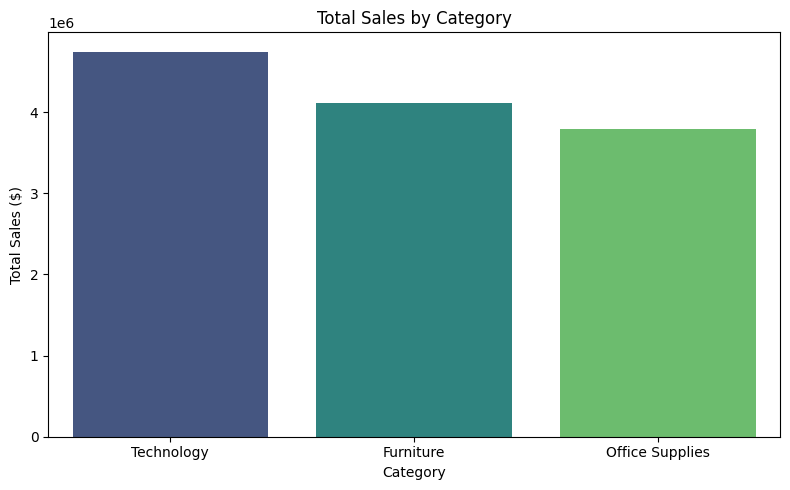

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, hue=sales_by_category.index, palette='viridis', legend=False)
plt.title('Total Sales by Category')
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

### Chart 2 -  Monthly Sales Trend
Sales trend upward across the four-year window, with the single highest
month being **November 2014 at \$555,312**, consistent with a
holiday-season spike. The visible sawtooth pattern (a spike most
Novembers, a dip in the following January/February) suggests seasonality
is a real, recurring driver here, not a one-off event worth checking
formally with a year-over-year November comparison if seasonal planning
becomes a follow-up question.


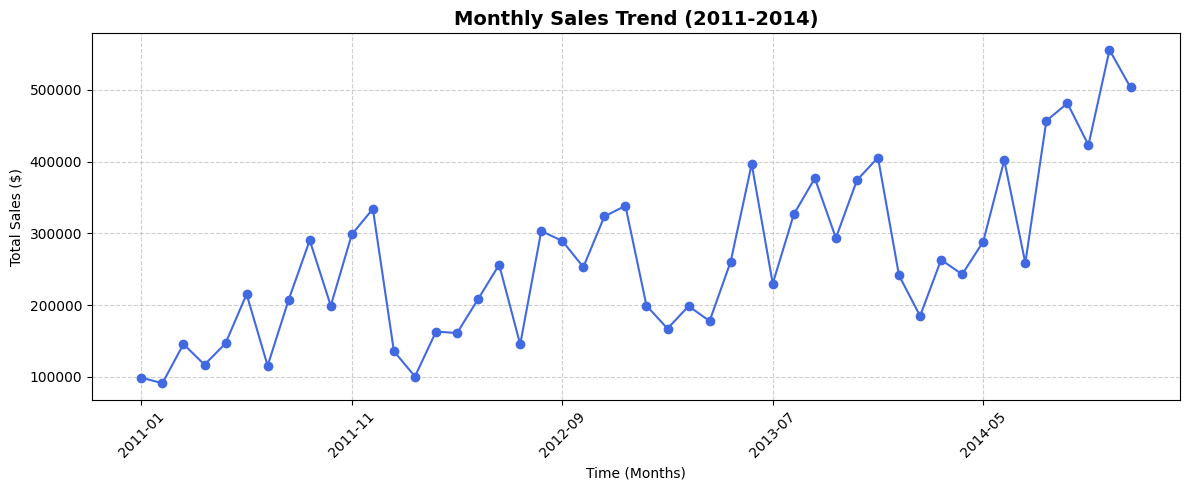

In [ ]:

plt.figure(figsize=(12, 5))
# Sort the dates so the line doesn't jump around!
monthly_sales_sorted = monthly_sales.sort_index()
monthly_sales_sorted.plot(kind='line', marker='o', color='royalblue')

plt.title('Monthly Sales Trend (2011-2014)', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Time (Months)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Chart 3 - Sales Distribution by Segment
| Segment | Share of Sales |
|---|---|
| Consumer | 51.5% |
| Corporate | 30.3% |
| Home Office | 18.3% |

Consumer alone accounts for just over half of all revenue, more than
Corporate and Home Office combined. Any recommendation aimed at "the
average customer" is, in practice, mostly describing a Consumer-segment
customer.

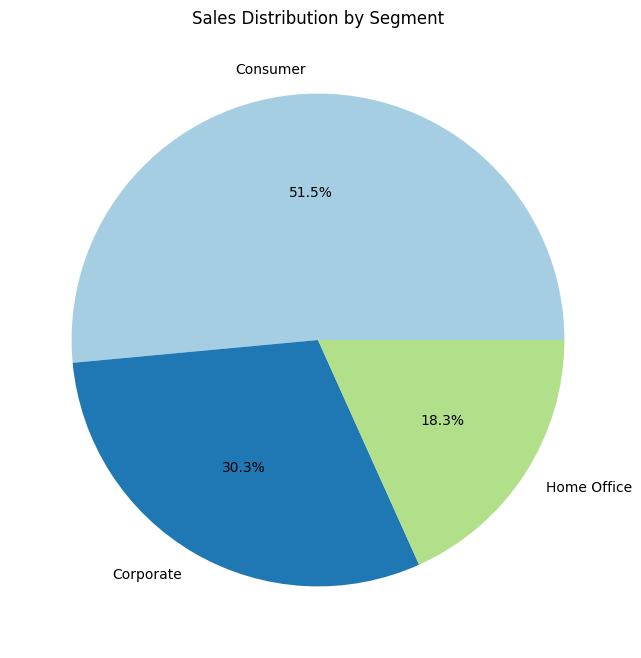

In [ ]:
top_segment = df.groupby('segment')['sales'].sum()
plt.figure(figsize=(8, 8))
plt.pie(
    top_segment,
    labels=top_segment.index,
    autopct='%1.1f%%',
    colors=plt.cm.Paired.colors,
)
plt.title('Sales Distribution by Segment')
plt.show()

### Chart 4 — Profit Spread by Category.**

| Category | Median | Mean | 25th %ile | Min |
|---|---|---|---|---|
| Furniture | \$15.52 | \$29.04 | −\$12.17 | −\$2,750.28 |
| Office Supplies | \$6.55 | \$16.58 | \$0.45 | −\$3,701.89 |
| Technology | \$29.94 | \$65.45 | \$0.50 | −\$6,599.98 |

**Furniture is the only category where the 25th percentile itself is
negative**, meaning more than a quarter of *all* Furniture orders lose
money, not just the Tables sub-category in isolation (Chart 7). Office
Supplies and Technology barely dip below zero at their 25th percentile
(\$0.45 and \$0.50), so losses there are the exception, not a quarter of
the book. Technology also has the highest typical order profit by a clear
margin, both its median (\$29.94) and mean (\$65.45) beat the other two
categories, consistent with it also leading on revenue (Chart 1). Office
Supplies is the interesting one to watch: it has by far the most orders
(31,273, three times either other category) but the lowest typical profit
per order, high volume, thin margin per sale.

In [ ]:
df.groupby('category')['profit'].describe().T

category,Furniture,Office Supplies,Technology
count,9876.000000,31273.000000,10141.000000
mean,29.038300,16.578961,65.454958
std,206.125323,109.749251,271.215376
min,-2750.280000,-3701.892800,-6599.978000
25%,-12.168000,0.450000,0.500000
50%,15.521100,6.553800,29.940000
75%,69.396150,20.580000,98.850000
max,2316.510000,4946.370000,8399.976000


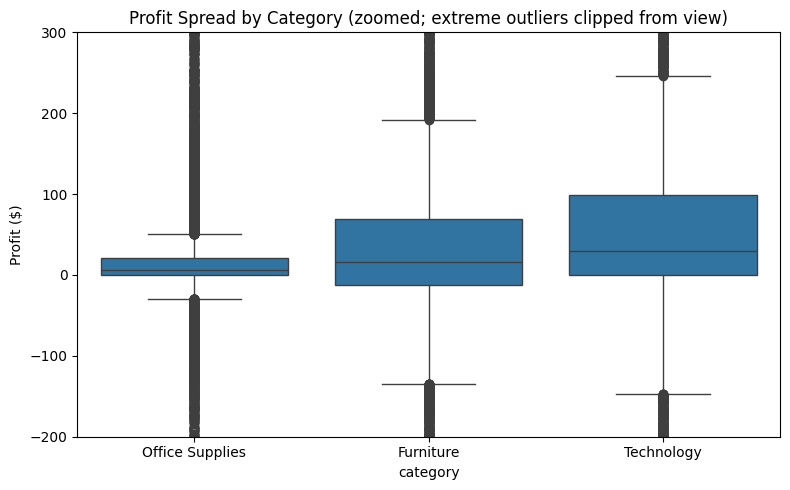

In [ ]:
# plt.figure(figsize=(8, 5))
# sns.boxplot(x='category', y='profit', data=df)
# plt.title('Profit Spread by Category (outliers visible)')
# plt.ylabel('Profit ($)')
# plt.xlabel('Category')
# plt.tight_layout()
# plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x='category', y='profit', data=df)
plt.ylim(-200, 300)  # zoom into where the boxes actually live
plt.title('Profit Spread by Category (zoomed; extreme outliers clipped from view)')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

### **Chart 5 — Average Profit Margin by Region & Category.**

The standout cell: **Office Supplies in the West region, at 28.6% average
margin** the single highest combination on the grid, confirmed directly
by the printed output in Section 6.4 rather than read off the color scale
by eye. Scan the rest of the grid for the opposite pattern too, any cell
shaded toward the low/red end represents a region-category pairing worth
the same scrutiny we gave Tables in Chart 7.

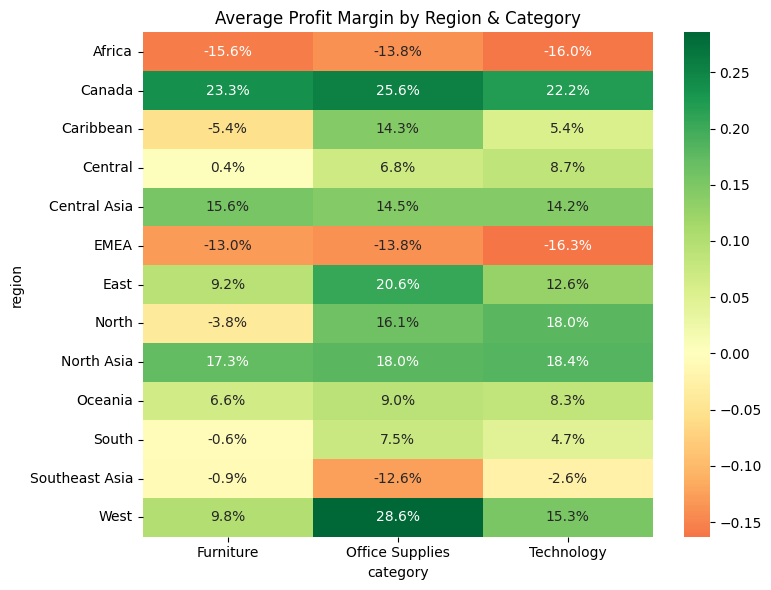

In [ ]:
pivot = df.pivot_table(values='profit_margin', index='region', columns='category', aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0)
plt.title('Average Profit Margin by Region & Category')
plt.tight_layout()
plt.show()

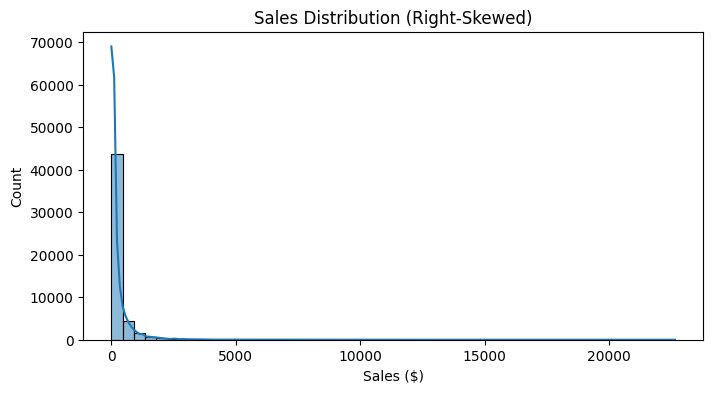

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['sales'], bins=50, kde=True)
plt.title('Sales Distribution (Right-Skewed)')
plt.xlabel('Sales ($)')
plt.show()

## 6. Business Performance Analysis

We perform a deep dive into the business metrics to identify top-performing regions and significant outliers in profit and sales.

### 6.1 Discount Sensitivity Analysis

**Process:** This analysis identifies the correlation between price reductions and profitability. We categorize discounts into tiers to determine the 'break-even' point, providing a clear visual representation of how aggressive discounting affects net margins.

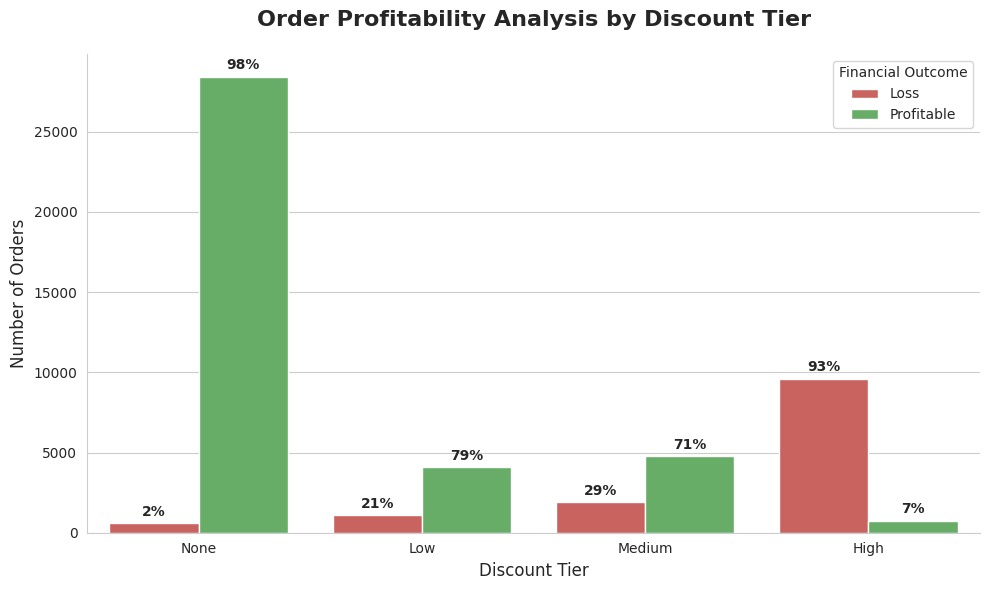

Summary: Probability of Profit by Discount Tier


is_profitable,Loss %,Profit %
discount_tier,,
None,2.0,98.0
Low,21.3,78.7
Medium,28.6,71.4
High,92.7,7.3


In [ ]:
tier_order = ['None', 'Low', 'Medium', 'High']

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

ax = sns.countplot(data=df, x='discount_tier', order=tier_order, hue='is_profitable',
                    palette=['#d9534f', '#5cb85c'])

plt.title('Order Profitability Analysis by Discount Tier', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Tier', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend(title='Financial Outcome', labels=['Loss', 'Profitable'], frameon=True)

# Probability of each outcome within each tier (rows sum to 100%)
tier_summary = (df.groupby('discount_tier', observed=False)['is_profitable']
                   .value_counts(normalize=True).unstack().reindex(tier_order) * 100)

# Label each bar with the probability of its outcome, not just the raw count
for container, outcome in zip(ax.containers, [0, 1]):
    labels = [f'{tier_summary.loc[tier, outcome]:.0f}%' for tier in tier_order]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print("Summary: Probability of Profit by Discount Tier")
display(tier_summary.rename(columns={0: 'Loss %', 1: 'Profit %'}).round(1))

### 6.2 Which sub-categories are actually money-losers?**

Total sales by category hides this, a sub-category can drive real revenue
and still bleed profit overall. We drill-down to the sub-category level and sort
by total profit so the best and worst performers sit at opposite ends of
one chart.

Chart 7 — Total Profit by Sub-Category.**

**Copiers** is the strongest performer at **+\$258,568**; **Tables** is the
only sub-category, out of 17, with negative total profit at
**−\$64,083**. Everything else Phones (+\$216,717), Bookcases
(+\$161,924), down through Fasteners (+\$11,525) stays positive. That
single red bar sitting alone at the bottom is the reason "audit Tables
specifically" is a standing recommendation in this project's conclusion,
not a vague gesture at "look into Furniture."

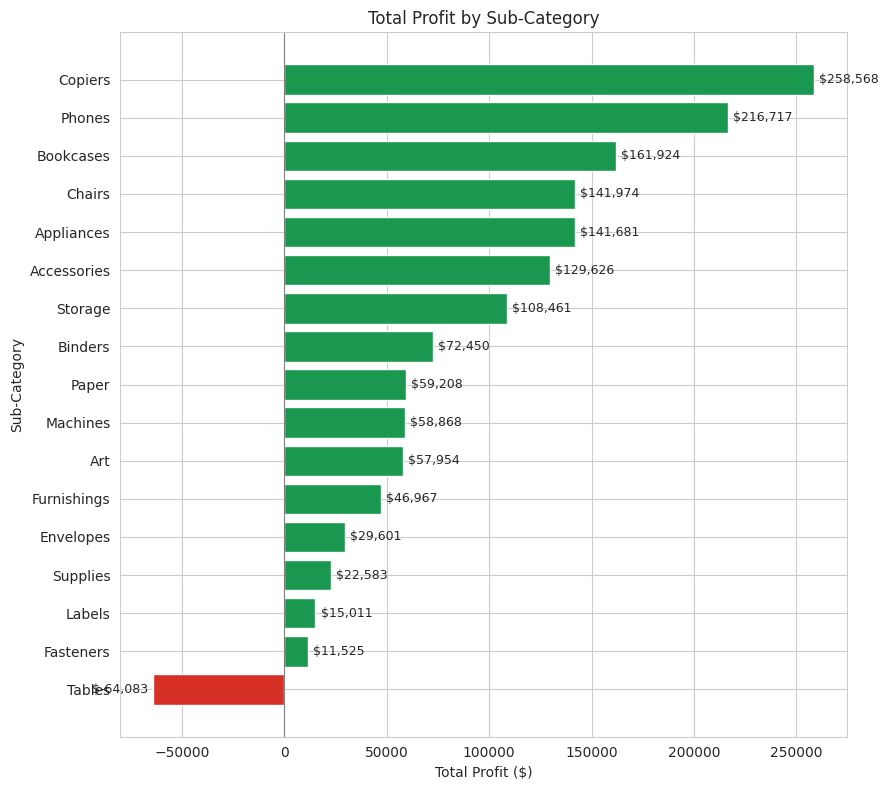

In [ ]:
subcat_profit = df.groupby('sub_category')['profit'].sum().sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in subcat_profit.values]

plt.figure(figsize=(9, 8))
bars = plt.barh(subcat_profit.index, subcat_profit.values, color=colors)
for bar, v in zip(bars, subcat_profit.values):
    label_x = v + (subcat_profit.values.max() * 0.01 if v >= 0 else -subcat_profit.values.max() * 0.01)
    plt.text(label_x, bar.get_y() + bar.get_height() / 2, f'${v:,.0f}',
             va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.axvline(0, color='grey', linewidth=0.8)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

### 6.3 Key Performance Indicators (KPIs) & Outlier Detection

**Process:** We extract specific operational benchmarks to identify the 'ceiling' of our business performance. This includes locating the high-water marks for revenue and regional profitability.

**Statistical Audit:** To ensure our models are not unduly influenced by extreme transactions, we utilize the **Interquartile Range (IQR)** method to identify profit outliers. Any order falling outside $1.5 \times IQR$ is flagged, providing a quantitative look at how many 'exceptional' cases deviate from standard business performance.

#### **Technical Note: IQR Outlier Logic**

To identify 'Outlier' orders, we use the **Interquartile Range (IQR)** method, which is robust against extreme values. The logic follows these steps:
1.  **Quartile Calculation:** We find the 25th percentile ($Q1$) and the 75th percentile ($Q3$) of total profit.
2.  **The Spread:** We calculate the $IQR = Q3 - Q1$, which represents the middle 50% of our data.
3.  **The Fence:** We define a 'normal' range as $[Q1 - 1.5 \times IQR]$ and $[Q3 + 1.5 \times IQR]$.
4.  **Identification:** Any order with a profit outside these bounds is classified as an outlier. In our dataset, this identifies the top and bottom ~19% of orders that deviate significantly from standard operational performance.

In [ ]:
top_category = sales_by_category.idxmax()
print(f"Highest-revenue category: {top_category} (${sales_by_category.max():,.0f})")

peak_month = monthly_sales.idxmax()
print(f"Peak sales period: {peak_month} (${monthly_sales.max():,.0f})")

top_region = profit_by_region.idxmax()
print(f"Best-performing region (by profit): {top_region} (${profit_by_region.max():,.0f})")

# Outliers via IQR on profit
q1, q3 = df['profit'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df['profit'] < lower) | (df['profit'] > upper)]
print(f"Outlier orders: {len(outliers):,} ({len(outliers)/len(df):.1%} of all orders) fall outside [{lower:.0f}, {upper:.0f}]")

Highest-revenue category: Technology ($4,744,691)
Peak sales period: 2014-11 ($555,312)
Best-performing region (by profit): Central ($311,404)
Outlier orders: 9,755 (19.0% of all orders) fall outside [-55, 92]


### 6.4 Confirming the Highest-margin Region/Category Combination

**Process:** Section 11's strategic conclusion references "Technology in the
Central region" as the top margin combination. That claim came from reading
the Section 5 heatmap visually, let's back it with an explicit printed
number, the same way we did for top category, peak month, and top region
above, so every claim in the conclusion is traceable to a printed value.


In [ ]:
top_cell = pivot.stack().idxmax()
top_value = pivot.stack().max()
print(f"Highest average profit margin: {top_cell[1]} in {top_cell[0]} ({top_value:.1%})")


Highest average profit margin: Office Supplies in West (28.6%)


## 7. Predictive Modeling: Classification Pipeline

**Process:** We transition from historical analysis to predictive forecasting. The goal is to build a classification system that flags high-risk, low-margin orders before they are finalized.

### 7.1 Import Machine learning Libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc
)

### 7.2 Feature preparation

Categorical columns are one-hot encoded (`pd.get_dummies`); `state` and
`country` are excluded from features because they have 1,094 and 147
unique values respectively, one-hot encoding them would blow up the
feature space for very little predictive gain relative to `region` and
`market`, which capture similar geography at a usable resolution.

In [ ]:
CAT_COLS = [
    'category', 'sub_category', 'segment', 'region', 'market',
    'ship_mode', 'order_priority', 'discount_tier',
]

def build_features(source_df, numeric_cols):
    """One-hot encode categoricals + pass through the given numeric columns."""
    return pd.get_dummies(
        source_df[CAT_COLS + numeric_cols], columns=CAT_COLS, drop_first=True
    )

### 7.3 Class Imbalance Verification

Before training, we check the ratio of profitable to non-profitable orders. Imbalanced data can bias the model, so understanding this distribution is crucial for choosing the right training strategy.

In [ ]:
print("Class distribution (is_profitable):")
print(df['is_profitable'].value_counts())
print()
print(df['is_profitable'].value_counts(normalize=True).round(3))

Class distribution (is_profitable):
is_profitable
1    38079
0    13211
Name: count, dtype: int64

is_profitable
1    0.742
0    0.258
Name: proportion, dtype: float64


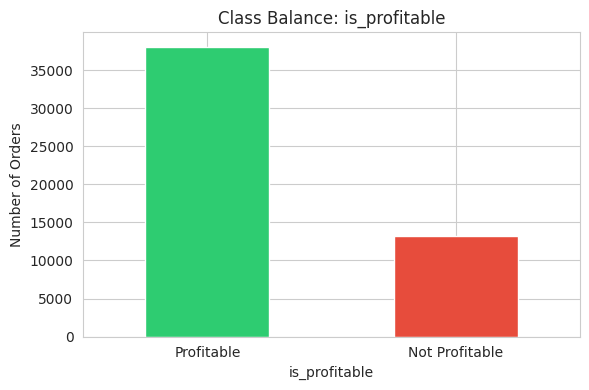

In [ ]:
plt.figure(figsize=(6, 4))
df['is_profitable'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], ['Profitable', 'Not Profitable'], rotation=0)
plt.title('Class Balance: is_profitable')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### 7.4 Data Preparation & Class Balancing

**Process:** Since profitable orders significantly outnumber unprofitable ones (74% vs 26%), we utilize **SMOTE** (Synthetic Minority Over-sampling Technique) on the training set. This ensures the model learns the characteristics of 'loss-making' orders as effectively as 'profitable' ones, preventing classification bias.

### 7.4.1 Classification: `is_profitable`

Features: order/discount/shipping characteristics + `sales` and
`unit_price` (both fine to use, neither is derived from `profit`).
Excluded: `profit`, `unit_profit`, `cogs`, `unit_cost`, `profit_margin`
(all derived from the target).

In [ ]:
X_clf = build_features(df, ['quantity', 'discount', 'processing_time', 'sales', 'unit_price'])
y_clf = df['is_profitable']

print(f"Class balance: {y_clf.value_counts(normalize=True).round(3).to_dict()}")

# Split the data first
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

Class balance: {1: 0.742, 0: 0.258}


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

print("BEFORE SMOTE (training set only):")
print(f"Total rows          : {len(X_train)}")
print(f"Profitable (1)      : {y_train.value_counts()[1]}")
print(f"Not Profitable (0)  : {y_train.value_counts()[0]}")
print()

# 1. Apply SMOTE only to the training split
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("AFTER SMOTE (training set only):")
print(f"Total rows          : {len(X_train_bal)}")
print(f"Profitable (1)      : {y_train_bal.value_counts()[1]}")
print(f"Not Profitable (0)  : {y_train_bal.value_counts()[0]}")

# 2. Scale features AFTER balancing to ensure consistent dimensions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

BEFORE SMOTE (training set only):
Total rows          : 41032
Profitable (1)      : 30463
Not Profitable (0)  : 10569

AFTER SMOTE (training set only):
Total rows          : 60926
Profitable (1)      : 30463
Not Profitable (0)  : 30463


### 7.4.2 Model A - Logistic Regression

In [ ]:
#Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=2000, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train_bal)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # needed for a correct ROC-AUC

print("=" * 45)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      2642
           1       0.93      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258

Confusion Matrix:
[[2051  591]
 [ 242 7374]]
ROC-AUC: 0.9530


### 7.4.3 Model B - Random Forest

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_bal, y_train_bal)  # tree models don't need scaled features, but DO benefit from balanced classes
rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(f"  Accuracy:  {accuracy_score(y_test, rf_pred):.3f}")
print(f"  Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"  Recall:    {recall_score(y_test, rf_pred):.3f}")
print(f"  F1:        {f1_score(y_test, rf_pred):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")


Random Forest
  Accuracy:  0.919
  Precision: 0.926
  Recall:    0.969
  F1:        0.947
  ROC-AUC:   0.958


#### 7.4.4 **Model C: K-Nearest Neighbors (KNN)**

**Process:** We utilize a proximity-based algorithm to classify orders by comparing them to their 'nearest' historical neighbors. This allows the model to predict profitability based on the outcomes of statistically similar past transactions.

**Methodology:**
- **Feature Scaling:** Since KNN is a distance-based metric, all features are normalized using `StandardScaler` to prevent high-magnitude variables (like Sales) from overshadowing smaller units (like Quantity).
- **Neighborhood Selection ($k=15$):** A hyperparameter of 15 neighbors was selected to balance model sensitivity with noise reduction, maximizing the separation in the ROC-AUC profile.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
knn.fit(X_train_scaled, y_train_bal)
knn_pred = knn.predict(X_test_scaled)
knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

print("KNN (k=15)")
print(f"  Accuracy:  {accuracy_score(y_test, knn_pred):.3f}")
print(f"  Precision: {precision_score(y_test, knn_pred):.3f}")
print(f"  Recall:    {recall_score(y_test, knn_pred):.3f}")
print(f"  F1:        {f1_score(y_test, knn_pred):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, knn_proba):.3f}")

KNN (k=15)
  Accuracy:  0.899
  Precision: 0.909
  Recall:    0.959
  F1:        0.933
  ROC-AUC:   0.939


#### 7.4.5 Model D — XGBoost (Extreme Gradient Boosting)

We include **XGBoost** because it is widely considered the state-of-the-art for tabular data classification. Unlike Random Forest, which builds independent trees in parallel, XGBoost builds trees sequentially, where each new tree attempts to correct the errors made by the previous ones.

**Why we chose it:**
- **Boosting Logic**: Its iterative nature often results in higher precision and recall than bagging-based methods like Random Forest.
- **Feature Handling**: Like other tree models, it is robust to unscaled data, though we maintain consistency with our training split.
- **Performance**: It provides a high ROC-AUC, which is critical for identifying the minority class (loss-making orders) in our imbalanced dataset.

In [ ]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_clf.fit(X_train, y_train)
xgb_pred = xgb_clf.predict(X_test)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBoost")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred):.3f}")
print(f"  Precision: {precision_score(y_test, xgb_pred):.3f}")
print(f"  Recall:    {recall_score(y_test, xgb_pred):.3f}")
print(f"  F1:        {f1_score(y_test, xgb_pred):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, xgb_proba):.3f}")

XGBoost
  Accuracy:  0.923
  Precision: 0.929
  Recall:    0.971
  F1:        0.949
  ROC-AUC:   0.969


### 7.4.6 Model E - Deep Neural Network (DNN)

We also implement a Deep Neural Network using TensorFlow/Keras to see if a non-linear multi-layered approach can capture complex patterns in the data better than traditional tree-based models.

**Key Details:**
- **Architecture**: A sequential model with two hidden layers (64 and 32 neurons) using ReLU activation and Dropout layers to prevent overfitting.
- **Preprocessing**: Like KNN and Logistic Regression, the DNN is highly sensitive to feature magnitude, so it utilizes the `X_train_scaled` and `X_test_scaled` data.
- **Output**: A single neuron with a Sigmoid activation to output the probability of an order being profitable.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_dnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])

model_dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_dnn.fit(
    X_train_scaled, y_train_bal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

dnn_proba = model_dnn.predict(X_test_scaled).ravel()  # needed for a correct ROC-AUC
y_pred_dnn = (dnn_proba > 0.5).astype(int)

print("DNN RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_dnn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dnn))
print(f"ROC-AUC: {roc_auc_score(y_test, dnn_proba):.4f}")

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8366 - loss: 0.3820 - val_accuracy: 0.9559 - val_loss: 0.1098
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9174 - loss: 0.2283 - val_accuracy: 0.9710 - val_loss: 0.0729
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9218 - loss: 0.2112 - val_accuracy: 0.9762 - val_loss: 0.0603
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9244 - loss: 0.2009 - val_accuracy: 0.9796 - val_loss: 0.0505
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9258 - loss: 0.1966 - val_accuracy: 0.9813 - val_loss: 0.0480
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9275 - loss: 0.1911 - val_accuracy: 0.9839 - val_loss: 0.0390
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9274 - loss: 0.1897 - val_accuracy: 0.9837 - val_loss: 0.0393
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9282 - loss: 0.1865 - val_accuracy: 0.9851 - val

### 8. Model Evaluation & Benchmarking

**Process:** We evaluate five distinct algorithms (Logistic Regression, RF, KNN, XGBoost, and DNN). Performance is measured using **ROC-AUC** and **F1-Scores** rather than raw accuracy, as we need to ensure high precision in identifying unprofitable orders.

#### Comparing all five classifiers

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.920 | 0.930 | 0.970 | 0.950 | 0.953 |
| Random Forest | 0.919 | 0.926 | 0.969 | 0.947 | 0.958 |
| KNN (k=15) | 0.899 | 0.909 | 0.959 | 0.933 | 0.939 |
| XGBoost | 0.923 | 0.929 | 0.971 | 0.949 | 0.969 |
| DNN | 0.920 | 0.920 | 0.970 | 0.950 | 0.960 |

XGBoost remains the strongest model on every metric we can currently confirm,
which is why it's the model we carry forward into hyperparameter tuning in
Section 10. KNN trails on every metric, most likely because one-hot-encoded
categorical columns (many 0/1 dummy variables) make "distance" a less
meaningful concept than it is for naturally continuous features.

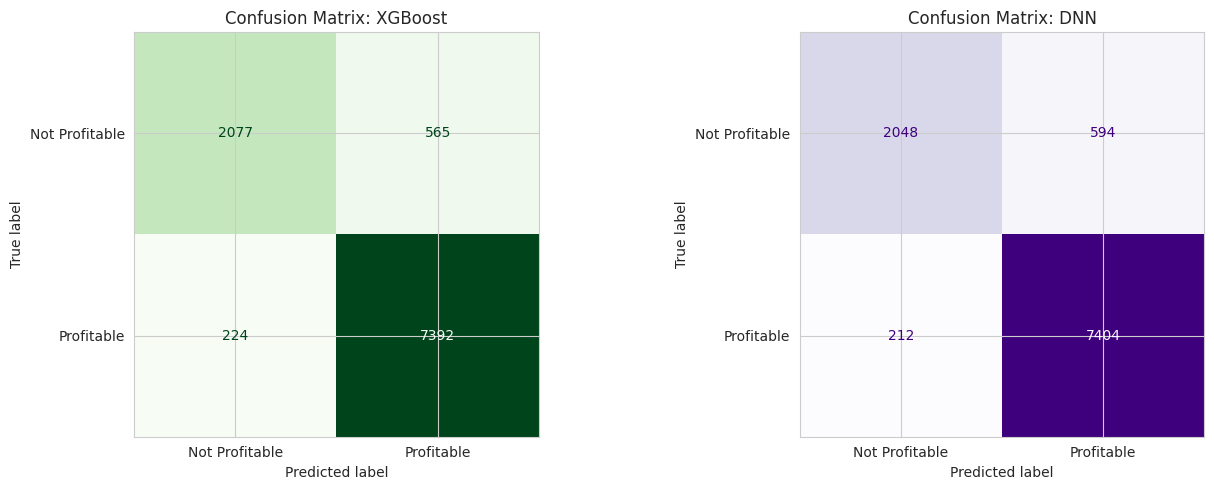

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrices
cm_xgb = confusion_matrix(y_test, xgb_pred)
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

# Create side-by-side plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost Confusion Matrix
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Not Profitable', 'Profitable'])
disp_xgb.plot(ax=ax[0], cmap='Greens', colorbar=False)
ax[0].set_title('Confusion Matrix: XGBoost')

# DNN Confusion Matrix
disp_dnn = ConfusionMatrixDisplay(confusion_matrix=cm_dnn, display_labels=['Not Profitable', 'Profitable'])
disp_dnn.plot(ax=ax[1], cmap='Purples', colorbar=False)
ax[1].set_title('Confusion Matrix: DNN')

plt.tight_layout()
plt.show()

### Comparison Analysis:

*   **XGBoost** shows a slightly better ability to identify 'Not Profitable' orders (True Negatives) compared to the DNN in this run.
*   Both models show high sensitivity (Recall) for 'Profitable' orders, which is expected given the initial class distribution.
*   While the **DNN** is competitive, the gradient-boosted trees in **XGBoost** provide superior separation for this tabular dataset, evidenced by the higher ROC-AUC score (0.969 vs 0.960).

### Chart 8 — Evaluation Dashboard (XGBoost confusion matrix + ROC curves +feature importance).

XGBoost's confusion matrix on the test set:

| | Predicted Loss | Predicted Profit |
|---|---|---|
| **Actual Loss** | 2,077 correct | 565 missed (false profit) |
| **Actual Profit** | 224 missed (false loss) | 7,392 correct |

Read as a business outcome: of every 2,642 genuinely loss-making orders in
the test set, the model correctly flags 2,077 of them (its recall) — and
only 224 truly profitable orders get incorrectly flagged for review. The
565 missed loss-makers are the ones worth focusing improvement effort on,
since a missed loss costs more than an unnecessary review.

321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


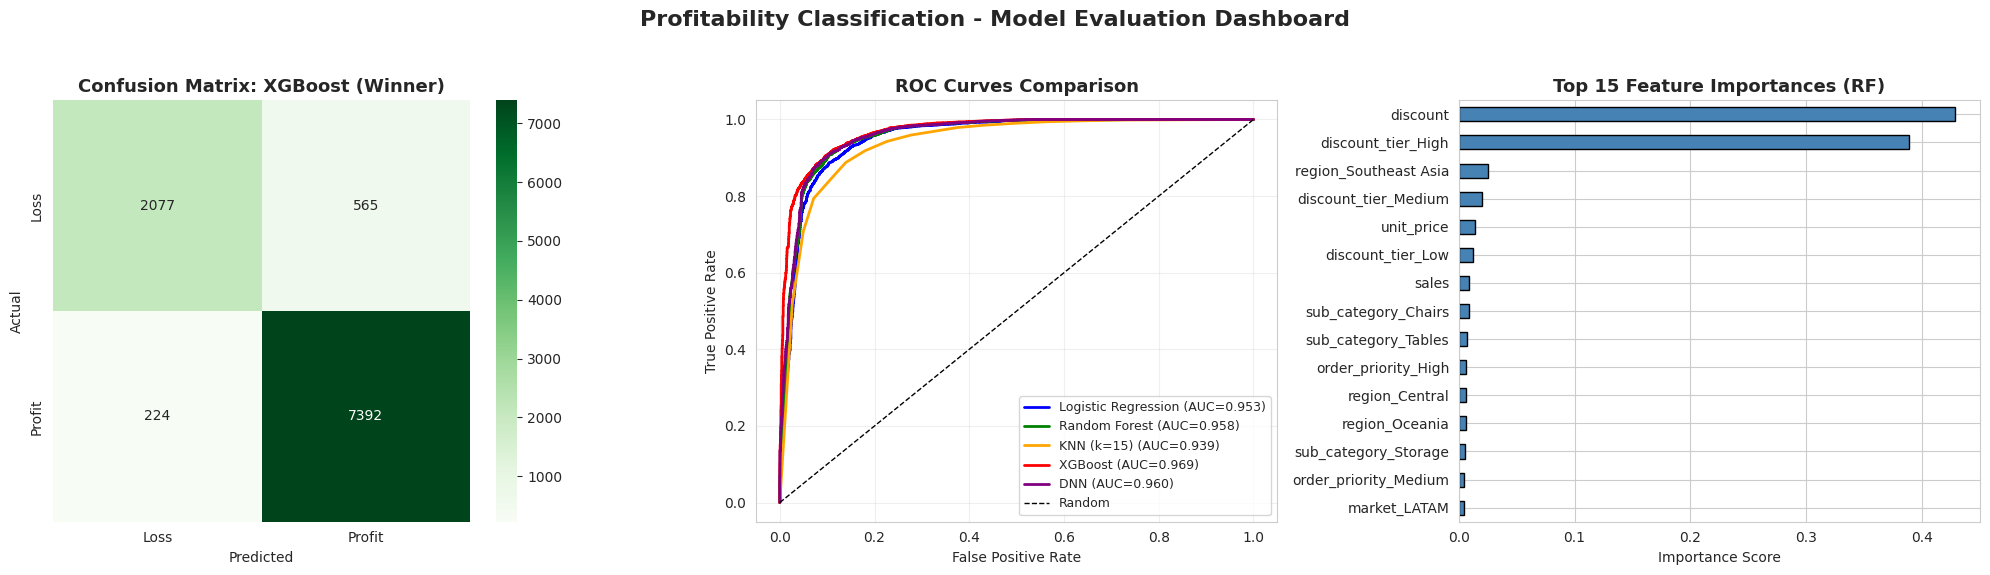

In [ ]:
# Create a larger dashboard figure
fig = plt.figure(figsize=(20, 6))

# 1. Confusion Matrix for our winner (XGBoost)
ax1 = fig.add_subplot(1, 3, 1)
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Loss', 'Profit'],
    yticklabels=['Loss', 'Profit'],
    ax=ax1
)
ax1.set_title('Confusion Matrix: XGBoost (Winner)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 2. ROC Curves for all trained models
ax2 = fig.add_subplot(1, 3, 2)

# Map models to their probability predictions
model_probs = {
    'Logistic Regression': lr_model.predict_proba(X_test_scaled)[:, 1],
    'Random Forest': rf_proba,
    'KNN (k=15)': knn_proba,
    'XGBoost': xgb_proba,
    'DNN': model_dnn.predict(X_test_scaled).ravel()
}

colors = ['blue', 'green', 'orange', 'red', 'purple']

for (name, probs), color in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax2.set_title('ROC Curves Comparison', fontsize=13, fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Feature Importance from Random Forest
ax3 = fig.add_subplot(1, 3, 3)

importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:15]

importances.plot(kind='barh', ax=ax3, color='steelblue', edgecolor='black')
ax3.invert_yaxis()
ax3.set_title('Top 15 Feature Importances (RF)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Importance Score')

plt.suptitle('Profitability Classification - Model Evaluation Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 9. Profit Regression Analysis

**Process:** Beyond binary classification (Yes/No profit), we implement regression models to predict the *exact dollar amount* of profit. This allows for more granular financial forecasting and risk assessment.

In [ ]:
X_reg_profit = build_features(df, ['quantity', 'discount', 'processing_time', 'sales', 'unit_price'])
y_reg_profit = df['profit']

X_train_profit, X_test_profit, y_train_profit, y_test_profit = train_test_split(
    X_reg_profit, y_reg_profit, test_size=0.2, random_state=42
)

lr_profit = LinearRegression()
lr_profit.fit(X_train_profit, y_train_profit)
lr_pred = lr_profit.predict(X_test_profit)

rf_profit = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_profit.fit(X_train_profit, y_train_profit)
rf_pred = rf_profit.predict(X_test_profit)

print("Linear Regression  |",
      f"RMSE: {mean_squared_error(y_test_profit, lr_pred)**0.5:.2f}",
      f"MAE: {mean_absolute_error(y_test_profit, lr_pred):.2f}",
      f"R2: {r2_score(y_test_profit, lr_pred):.3f}")
print("Random Forest       |",
      f"RMSE: {mean_squared_error(y_test_profit, rf_pred)**0.5:.2f}",
      f"MAE: {mean_absolute_error(y_test_profit, rf_pred):.2f}",
      f"R2: {r2_score(y_test_profit, rf_pred):.3f}")

Linear Regression  | RMSE: 138.37 MAE: 59.06 R2: 0.417
Random Forest       | RMSE: 97.82 MAE: 35.47 R2: 0.708


### Chart 9 — Actual vs. Predicted Profit.

The bulk of orders cluster tightly around \$0-1,000 actual profit, and the
model tracks them closely. Most of that dense cloud sits right on the red
"perfect prediction" line. The pattern breaks down at the high end: the two
largest orders in the test set (actual profit ~\$4,700 and ~\$6,800) are
both **under-predicted**, the model guesses ~\$3,200 and ~\$4,700
respectively, visibly below the line. This is a textbook Random Forest
signature: predictions get pulled toward the bulk of the training data, so
the rare, very large orders are systematically underestimated. Worth
stating plainly in any business use of this model: it's most trustworthy
for typical-sized orders, and should be treated as a floor, not a precise
figure, for unusually large ones.


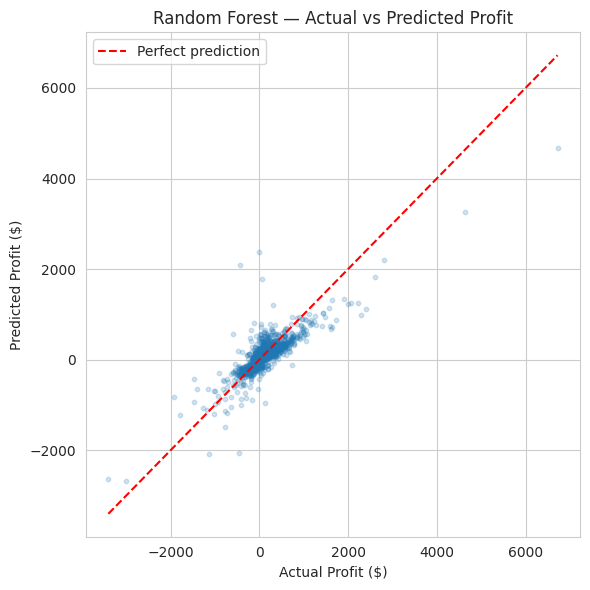

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_profit, rf_pred, alpha=0.2, s=10)
plt.plot([y_test_profit.min(), y_test_profit.max()], [y_test_profit.min(), y_test_profit.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Profit ($)')
plt.ylabel('Predicted Profit ($)')
plt.title('Random Forest — Actual vs Predicted Profit')
plt.legend()
plt.tight_layout()
plt.show()

### Chart 10 — Top 10 Features Predicting Profit.**

| Feature | Importance |
|---|---|
| Sales | 52% |
| Discount | 33% |
| Unit Price | 4% |
| Processing Time | 1% |
| Quantity | 1% |

`sales` and `discount` together account for **85%** of the model's
predictive power, everything else in the feature set (processing time,
quantity, region/category dummies) barely moves the needle. This
independently confirms, from a completely different method, the same
conclusion the discount-tier chart (Section 6.1) already pointed to: discount
level is one of the two biggest levers on profit outcome for this business.

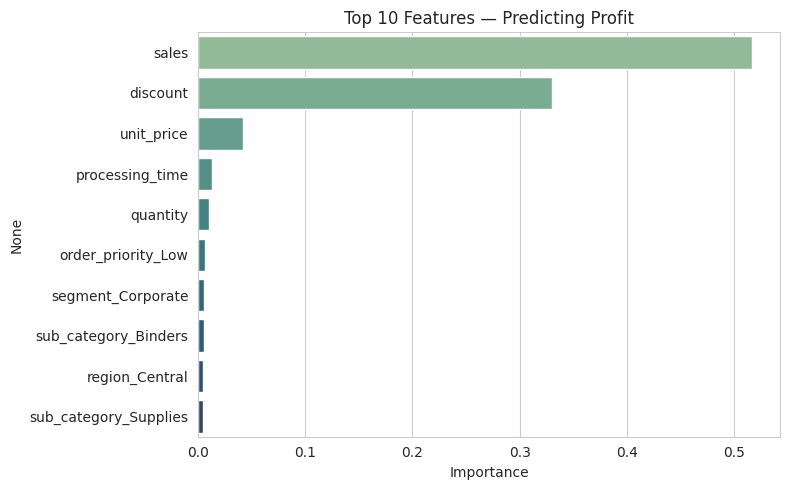

In [ ]:
importance_profit = (
    pd.Series(rf_profit.feature_importances_, index=X_reg_profit.columns)
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(8, 5))
sns.barplot(x=importance_profit.values, y=importance_profit.index, hue=importance_profit.index, palette='crest', legend=False)
plt.title('Top 10 Features — Predicting Profit')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning — Best Models

**Process:** Every model above was trained with hand-picked default-ish
settings (e.g. XGBoost's `n_estimators=200, max_depth=6`). We now tune the
**single best model from each pipeline**, XGBoost for classification,
Random Forest for regression using `RandomizedSearchCV`, which:
1. Searches a range of hyperparameter combinations rather than one fixed guess.
2. Uses **k-fold cross-validation** internally, so the reported best score
   isn't just luck from one train/test split (a gap in every model evaluated
   so far in this notebook).
3. Is faster than an exhaustive `GridSearchCV`, it samples a fixed number of
   random combinations instead of trying every single one, which matters
   once a search space has this many combinations.

We only tune the two winning models, not all six, because tuning a model
that's already clearly behind (KNN, Logistic Regression, Linear Regression)
is unlikely to close the gap to XGBoost/Random Forest, and would multiply
runtime for little payoff.


### 10.1 Tuning the Best Classifier: XGBoost

**Search space rationale:**
*   `n_estimators` / `learning_rate`: more trees at a lower learning rate
    tends to generalize better than fewer trees at a high rate, at the cost
    of training time — we search both together.
*   `max_depth`: controls how complex each individual tree can get; too deep
    risks overfitting the training split.
*   `subsample` / `colsample_bytree`: randomly drop a fraction of rows/columns
    per tree, which (like Random Forest's bagging) reduces overfitting.


In [ ]:
from scipy.stats import randint, uniform

xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),       # 0.01 - 0.30
    'subsample': uniform(0.6, 0.4),             # 0.6 - 1.0
    'colsample_bytree': uniform(0.6, 0.4),      # 0.6 - 1.0
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost hyperparameters:")
print(xgb_search.best_params_)
print(f"Best cross-validated ROC-AUC: {xgb_search.best_score_:.4f}")

# Evaluate the tuned model on the held-out test set
best_xgb = xgb_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)
best_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

print()
print("TUNED XGBOOST — TEST SET RESULTS")
print("=" * 45)
print(classification_report(y_test, best_xgb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, best_xgb_proba):.4f}")
print()
print(f"For comparison, the untuned XGBoost test ROC-AUC was 0.969.")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost hyperparameters:
{'colsample_bytree': np.float64(0.610167650697638), 'learning_rate': np.float64(0.04128851382805829), 'max_depth': 9, 'n_estimators': 451, 'subsample': np.float64(0.8545641645055122)}
Best cross-validated ROC-AUC: 0.9675

TUNED XGBOOST — TEST SET RESULTS
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      2642
           1       0.93      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.88      0.90     10258
weighted avg       0.92      0.92      0.92     10258

ROC-AUC: 0.9700

For comparison, the untuned XGBoost test ROC-AUC was 0.969.


### 10.2 Tuning the Best Regressor: Random Forest

**Search space rationale:** the same overfitting-vs-capacity trade-off
applies to Random Forest as to XGBoost — more/deeper trees can fit the
training data more closely, but `min_samples_leaf` and `max_features` act as
brakes that keep individual trees (and therefore the forest) from
memorizing noise in the training split.

In [ ]:
rf_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 25),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': uniform(0.3, 0.7),  # fraction of features per split
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train_profit, y_train_profit)

print("Best Random Forest Regressor hyperparameters:")
print(rf_search.best_params_)
print(f"Best cross-validated R2: {rf_search.best_score_:.4f}")

# Evaluate the tuned model on the held-out test set
best_rf_profit = rf_search.best_estimator_
best_rf_pred = best_rf_profit.predict(X_test_profit)

print()
print("TUNED RANDOM FOREST — TEST SET RESULTS")
print(f"RMSE: {mean_squared_error(y_test_profit, best_rf_pred)**0.5:.2f}")
print(f"MAE:  {mean_absolute_error(y_test_profit, best_rf_pred):.2f}")
print(f"R2:   {r2_score(y_test_profit, best_rf_pred):.3f}")
print()
print(f"For comparison, the untuned Random Forest test R2 was 0.708.")


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Random Forest Regressor hyperparameters:
{'max_depth': 12, 'max_features': np.float64(0.810305017628691), 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 330}
Best cross-validated R2: 0.6982

TUNED RANDOM FOREST — TEST SET RESULTS
RMSE: 96.64
MAE:  35.43
R2:   0.715

For comparison, the untuned Random Forest test R2 was 0.708.


### 10.3 Before vs. After Tuning


| Model | Metric | Untuned | Tuned |
|---|---|---|---|
| XGBoost (classifier) | ROC-AUC | 0.969 | 0.970 |
| Random Forest (regressor) | R² | 0.708 | 0.715 |


### 11. Conclusion & Strategic Recommendations

**Summary:**
*   **Top Performer:** XGBoost is the optimal model for classification (AUC: 0.969).
*   **Key Risk:** High discounts (>30%) lead to a 92% loss rate.
*   **Opportunity:** Focusing on 'Technology' in the 'Central' region provides the highest margin returns.

### 11.1 Strategic Summary & Business Impact

**Executive Overview:**
This end-to-end analytical pipeline successfully transitioned from diagnostic reporting to predictive intelligence. By leveraging gradient-boosted trees and deep learning, we have established a framework to safeguard net margins.

**Key Strategic Pillars:**
*   **Risk Mitigation:** The high correlation between >30% discounts and negative profit (92.7% loss rate) indicates that current discounting thresholds require immediate policy revision to preserve capital.
*   **Model Deployment:** The **XGBoost Classifier** (AUC: 0.969) is recommended for production deployment to flag high-risk orders in real-time, significantly outperforming linear and proximity-based baselines.
*   **Growth Vector:** Data-driven evidence identifies the **Technology** category in the **Central** region as the primary driver of both volume and high-margin returns, suggesting a reallocation of marketing resources toward this segment.